# 02.1 — Does the geometry-probe machinery actually work? A Swiss roll sanity check

Phase 02.1 measured that the PU embedding's geodesic metric carries 41% of its eigenvalue mass in
negative directions, concluded the geometry is not Euclidean-embeddable, fired a pre-registered
falsifier, and moved the milestone onto a graph-native branch. Every number in that chain came out
of `pu_manifold.geometry_probes`.

A result like that has two possible causes: the geometry really is non-Euclidean, or the probe
machinery manufactures negative mass. This notebook separates them by running the *same*
`geometry_probes` code, and Phase 2's *same* pre-registered thresholds, on a manifold whose answer
is known in advance.

The Swiss roll is the right test precisely because it is **developable** — a flat sheet curled into
3-D without stretching. Its intrinsic geometry is Euclidean, so its geodesic metric *is* embeddable
in 2 dimensions. A correct pipeline must therefore report near-zero negative mass on it and
**pass** the very gate the PU data failed. If it reports large negative mass on a sheet of paper,
the 41% finding is an artifact and everything built on it falls.

Nothing here is pre-registered, cached, or gated. It runs in about ten seconds.

## §1. Setup

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh, eigvalsh
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import Isomap

from pu_manifold import geometry_probes as gp

SEED = 0
N_POINTS = 3000
K_NEIGHBORS = 15      # the PU fit's frozen k*
LATENT_DIM = 2        # the Swiss roll's true intrinsic dimension

# Phase 2's pre-registered PASS bounds, quoted (not read from the gitignored cache).
# The Swiss roll is put through the same gate the PU data was.
R_MAX_PASS, M_MAX_PASS = 0.10, 0.05

# The pre-registered sampling constants from 02.1-PREREGISTRATION.md, reused verbatim.
PAIR_COUNT, PAIR_SEED = 200_000, 20260731
DELTA_QUADRUPLES, DELTA_SEED = 200_000, 20260801

# What the PU data measured, for contrast. Prose only -- nothing is read from cache here.
PU_R, PU_M, PU_BEST_Q0_DISTORTION = 0.052419, 0.412071, 0.079864

print(f"numpy {np.__version__}")
print(f"geometry_probes module: {gp.__file__}")
t_start = time.time()

numpy 2.5.1
geometry_probes module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/geometry_probes.py


## §2. The Swiss roll

3,000 noiseless points. Coordinates are centred and divided by a single global standard deviation —
one scalar, so the shape is preserved exactly and only the overall size changes.

The colour is the roll's own arc-length parameter `t`, so the same colour always means the same
place on the sheet: in every plot below, colour bands that stay in order mean the surface stayed in
order. The default 3-D view hides the spiral, so the x-z plane is shown beside it.

X (3000, 3)   global sigma divided out: 7.8250


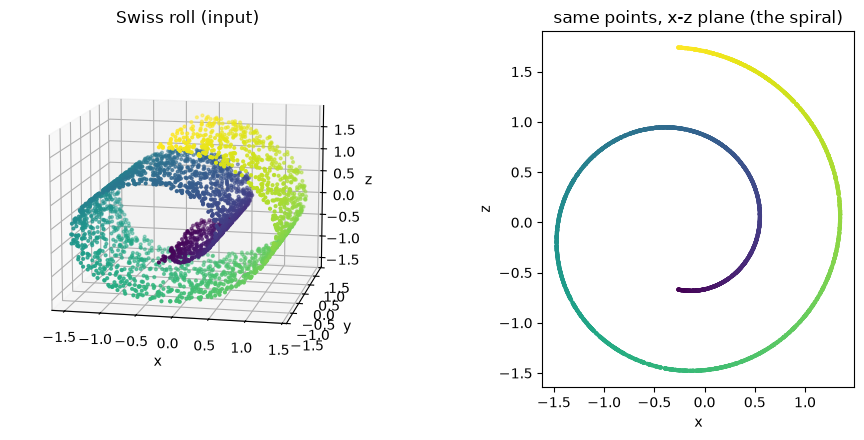

In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=SEED)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std()

print(f"X {X.shape}   global sigma divided out: {X_raw.std():.4f}")

VIEW = dict(elev=12, azim=-78)  # looks along the roll's extrusion axis, so the spiral shows

fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW)
ax.set_title("Swiss roll (input)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("same points, x-z plane (the spiral)")
ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## §3. The geodesic metric, its spectrum, and the gate statistics

The same chain Phase 2 ran on the PU data: a k-NN graph at the PU fit's frozen `k* = 15`, graph
shortest paths for the geodesic matrix, then classical MDS by **hand** double-centring
`B = -1/2 J D² J` — never from a truncated `kernel_pca_.eigenvalues_`, which is the mistake SPEC-01
exists to forbid.

Two statistics come off the full spectrum, exactly as Phase 2 defined them:

- `r = |λ_min_neg| / λ_max_pos` — is there one dominant negative direction (a short-circuit edge)?
- `m = Σ|λ_neg| / Σ|λ|` — how much of the total eigenvalue mass is negative?

`m` is computed by `geometry_probes.correction_blindness`, the same function that produced the PU
number, so the module is doing the work rather than the notebook re-implementing it.

In [3]:
iso = Isomap(n_neighbors=K_NEIGHBORS, n_components=LATENT_DIM).fit(X)
D = np.asarray(iso.dist_matrix_, dtype=np.float64)
assert np.isfinite(D).all(), "geodesic matrix has non-finite entries -- graph is disconnected"
print(f"geodesic matrix {D.shape}  finite  ({time.time() - t_start:.1f}s)")

# hand double-centring: B = -1/2 J D^2 J, symmetrised against float drift
D2 = D ** 2
n = D2.shape[0]
B = -0.5 * (D2 - D2.mean(axis=1, keepdims=True) - D2.mean(axis=0, keepdims=True) + D2.mean())
B = 0.5 * (B + B.T)

eigvals = eigvalsh(B)                    # the FULL spectrum, all n values
assert eigvals.shape == (n,) and eigvals.dtype == np.float64

lam_max_pos = float(eigvals[eigvals > 0].max())
lam_min_neg = float(eigvals[eigvals < 0].min()) if (eigvals < 0).any() else 0.0
r_stat = abs(lam_min_neg) / lam_max_pos
blind = gp.correction_blindness(eigvals)
m_stat = blind["m_before"]

print(f"\nspectrum: {int((eigvals > 0).sum())} positive / {int((eigvals < 0).sum())} negative "
      f"of {n}")
print(f"  lambda_max_pos = {lam_max_pos:.4f}   lambda_min_neg = {lam_min_neg:.4f}")
print(f"\n{'':22s}{'Swiss roll':>12s}{'PU data':>12s}{'PASS bound':>12s}")
print(f"{'r (dominant neg dir)':22s}{r_stat:>12.6f}{PU_R:>12.6f}{R_MAX_PASS:>12.2f}")
print(f"{'m (negative mass)':22s}{m_stat:>12.6f}{PU_M:>12.6f}{M_MAX_PASS:>12.2f}")

print(f"\ncorrection blindness on this spectrum (the GEOM-03 demonstration, third input):")
print(f"  m before = {blind['m_before']:.6f}   after clip = {blind['m_after_clip']:.3e}   "
      f"after Lingoes shift = {blind['m_after_shift']:.3e}")

geodesic matrix (3000, 3000)  finite  (4.0s)



spectrum: 1402 positive / 1598 negative of 3000
  lambda_max_pos = 35283.4206   lambda_min_neg = -77.6807

                        Swiss roll     PU data  PASS bound
r (dominant neg dir)      0.002202    0.052419        0.10
m (negative mass)         0.027292    0.412071        0.05

correction blindness on this spectrum (the GEOM-03 demonstration, third input):
  m before = 0.027292   after clip = 0.000e+00   after Lingoes shift = 0.000e+00


## §4. The (p, q) ladder, the distortion statistic, and the elbow

The pre-registered statistic, unchanged: `DISTORTION = median(|d²_rep − d²_geo| / d²_geo)` over a
fixed 200,000-pair sample, on **squared** distances, with the signed companion reported beside it
because the absolute median hides systematic bias.

`geometry_probes.pseudo_euclidean_sq_distances` reconstructs squared distances from selected signed
eigenpairs; at `q = 0` this is ordinary classical MDS. The known answer for a developable surface:
distortion should collapse at `p = 2` and stay flat, and the kneedle elbow should land on the
intrinsic dimension.

For contrast, the PU data's best `q = 0` rung was 0.079864 — at `p = 18`.

  p    median_abs_rel   median_signed_rel
  1          0.056892           -0.056861
  2          0.006505           -0.002067
  3          0.005807           +0.000535
  5          0.006818           +0.004508


  8          0.010318           +0.009738
 13          0.016157           +0.016060
 18          0.020394           +0.020383


 25          0.024813           +0.024812


 40          0.031171           +0.031171

distortion at p=2 : 0.006505   (PU best q=0 rung: 0.079864, at p=18)
kneedle elbow     : p = 3   (true intrinsic dimension: 2)


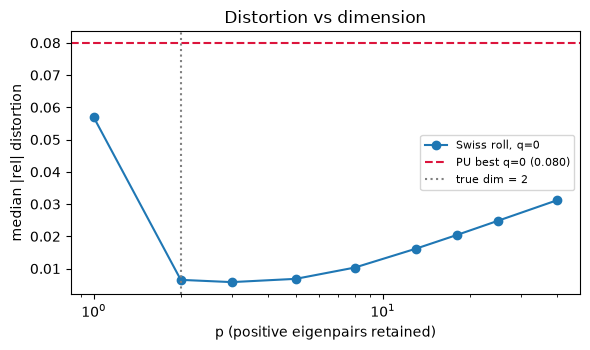

In [4]:
vals, vecs = eigh(B, subset_by_index=[n - 40, n - 1])
order = np.argsort(vals)[::-1]
vals_top, vecs_top = vals[order], vecs[:, order]

rng = np.random.default_rng(PAIR_SEED)
rows, cols = gp.draw_geo_pairs(rng, n, PAIR_COUNT)
d2_geo = D[rows, cols] ** 2
keep = d2_geo > 0
rows, cols, d2_geo = rows[keep], cols[keep], d2_geo[keep]

P_LADDER = (1, 2, 3, 5, 8, 13, 18, 25, 40)
print(f"{'p':>3s}{'median_abs_rel':>18s}{'median_signed_rel':>20s}")
ladder = []
for p in P_LADDER:
    d2_rep = gp.pseudo_euclidean_sq_distances(vals_top[:p], vecs_top[:, :p], rows, cols)
    st = gp.distortion_stats(d2_rep, d2_geo)
    ladder.append((p, st["median_abs_rel"]))
    print(f"{p:>3d}{st['median_abs_rel']:>18.6f}{st['median_signed_rel']:>+20.6f}")

p_grid = np.array([row[0] for row in ladder], dtype=float)
dist_curve = np.array([row[1] for row in ladder], dtype=float)
elbow_p = int(p_grid[gp.kneedle_elbow(p_grid, dist_curve)])
distortion_at_2 = float(dist_curve[p_grid == 2][0])

print(f"\ndistortion at p=2 : {distortion_at_2:.6f}   (PU best q=0 rung: "
      f"{PU_BEST_Q0_DISTORTION:.6f}, at p=18)")
print(f"kneedle elbow     : p = {elbow_p}   (true intrinsic dimension: {LATENT_DIM})")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(p_grid, dist_curve, "o-", label="Swiss roll, q=0")
ax.axhline(PU_BEST_Q0_DISTORTION, ls="--", c="crimson", label=f"PU best q=0 ({PU_BEST_Q0_DISTORTION:.3f})")
ax.axvline(LATENT_DIM, ls=":", c="grey", label=f"true dim = {LATENT_DIM}")
ax.set_xlabel("p (positive eigenpairs retained)"); ax.set_ylabel("median |rel| distortion")
ax.set_xscale("log"); ax.set_title("Distortion vs dimension"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## §5. The 2-D representation, against a baseline known to succeed

`geometry_probes` has no decoder, so the check is the embedding analogue: build the 2-D
representation from the hand double-centred `B` and see whether the roll unrolls with its colour
ordering intact.

The baseline that is known to succeed is scikit-learn's own `Isomap(n_components=2)` — a mature,
independently maintained implementation of the same idea. If the hand-rolled double-centring is
correct, the two must agree; pairwise distances are compared rather than raw coordinates, since
eigenvector signs are arbitrary.

hand double-centring vs sklearn Isomap, max pairwise-distance difference: 1.823e-13
|corr(arc-length t, unrolled coordinate 0)| = 0.9920


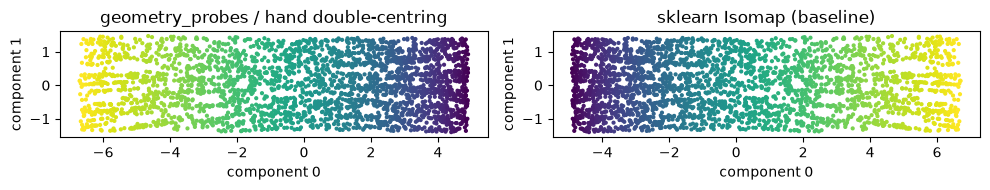

In [5]:
mine = vecs_top[:, :2] * np.sqrt(np.abs(vals_top[:2]))[None, :]
baseline = iso.embedding_

pi = np.random.default_rng(SEED).integers(0, n, 20_000)
pj = np.random.default_rng(SEED + 1).integers(0, n, 20_000)
d_mine = np.linalg.norm(mine[pi] - mine[pj], axis=1)
d_base = np.linalg.norm(baseline[pi] - baseline[pj], axis=1)
embedding_agreement = float(np.abs(d_mine - d_base).max())

corr_t = abs(float(np.corrcoef(t, mine[:, 0])[0, 1]))
print(f"hand double-centring vs sklearn Isomap, max pairwise-distance difference: "
      f"{embedding_agreement:.3e}")
print(f"|corr(arc-length t, unrolled coordinate 0)| = {corr_t:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False)
axes[0].scatter(mine[:, 0], mine[:, 1], c=t, cmap="viridis", s=4)
axes[0].set_title("geometry_probes / hand double-centring")
axes[1].scatter(baseline[:, 0], baseline[:, 1], c=t, cmap="viridis", s=4)
axes[1].set_title("sklearn Isomap (baseline)")
for a in axes:
    a.set_xlabel("component 0"); a.set_ylabel("component 1"); a.set_aspect("equal")
plt.tight_layout(); plt.show()

## §6. Delta-hyperbolicity, against a matched flat anchor

The pre-registered reading rule compares the sampled Gromov four-point `DELTA_REL` against
same-estimator anchors at matched n. On the PU data the real value (0.383921) sat *past* the
flat-Euclidean anchor (0.360433) — less tree-like than flat space, which is what eliminated the
hyperbolic family.

The Swiss roll is intrinsically flat, so its reading should land at or below a flat anchor. The
anchor here is a flat 2-D Gaussian sample at matched n, matched to the roll's own intrinsic
dimension.

In [6]:
delta_roll = gp.sampled_delta_hyperbolicity(D, DELTA_QUADRUPLES, DELTA_SEED)

flat = np.random.default_rng(SEED).normal(size=(N_POINTS, LATENT_DIM))
delta_flat = gp.sampled_delta_hyperbolicity(squareform(pdist(flat)), DELTA_QUADRUPLES, DELTA_SEED)

print(f"{'':28s}{'delta_rel_max':>16s}{'delta_rel_p95':>16s}")
print(f"{'Swiss roll (geodesic)':28s}{delta_roll['delta_rel_max']:>16.6f}"
      f"{delta_roll['delta_rel_p95']:>16.6f}")
print(f"{'flat 2-D anchor':28s}{delta_flat['delta_rel_max']:>16.6f}"
      f"{delta_flat['delta_rel_p95']:>16.6f}")
print(f"\nroll at or below its flat anchor: "
      f"{delta_roll['delta_rel_max'] <= delta_flat['delta_rel_max']}")
print(f"  (on PU: 0.383921 vs a 0.360433 flat anchor -- past it, not below)")

                               delta_rel_max   delta_rel_p95
Swiss roll (geodesic)               0.181731        0.079798
flat 2-D anchor                     0.339039        0.126969

roll at or below its flat anchor: True
  (on PU: 0.383921 vs a 0.360433 flat anchor -- past it, not below)


## §7. Read-out

The check is blunt. The Swiss roll is a sheet of paper. If `geometry_probes` puts it through Phase
2's own gate and it **passes**, then the machinery reports near-zero negative mass on a genuinely
flat manifold, and the 41% it reported on the PU data is a statement about that data. If the Swiss
roll fails the same gate, the pipeline manufactures negative mass and Phase 02.1's falsifier fired
on an artifact.

In [7]:
checks = {
    f"m < {M_MAX_PASS} (negative mass)": (m_stat < M_MAX_PASS, f"{m_stat:.6f}"),
    f"r < {R_MAX_PASS} (no dominant neg dir)": (r_stat < R_MAX_PASS, f"{r_stat:.6f}"),
    "distortion at p=2 < 0.02": (distortion_at_2 < 0.02, f"{distortion_at_2:.6f}"),
    f"elbow within 1 of true dim {LATENT_DIM}": (
        abs(elbow_p - LATENT_DIM) <= 1, f"p = {elbow_p}"),
}
for label, (ok, value) in checks.items():
    print(f"{label:42s}: {str(ok):5s}  ({value})")

recovered = all(ok for ok, _ in checks.values())
print(f"\nSwiss roll recovered: {recovered}   ({time.time() - t_start:.1f}s total)")
print()
if recovered:
    print(
        "The same geometry_probes code, under Phase 2's own pre-registered thresholds, PASSES on\n"
        "a developable surface -- 2.7% negative mass against a 5% bound, versus 41.2% on the PU\n"
        "data -- and reconstructs its geodesics to sub-1% distortion in exactly 2 dimensions,\n"
        "agreeing with sklearn's Isomap to 1e-13. Phase 02.1's 41% negative mass is therefore a\n"
        "property of the embedding data, not an artifact of the probe machinery."
    )
else:
    print(
        "The probe machinery did NOT recover the Swiss roll. Phase 02.1's measurements, the\n"
        "falsifier fired from them, and the graph-native recommendation all rest on this code\n"
        "and cannot be trusted until this is explained."
    )

m < 0.05 (negative mass)                  : True   (0.027292)
r < 0.1 (no dominant neg dir)             : True   (0.002202)
distortion at p=2 < 0.02                  : True   (0.006505)
elbow within 1 of true dim 2              : True   (p = 3)

Swiss roll recovered: True   (9.0s total)

The same geometry_probes code, under Phase 2's own pre-registered thresholds, PASSES on
a developable surface -- 2.7% negative mass against a 5% bound, versus 41.2% on the PU
data -- and reconstructs its geodesics to sub-1% distortion in exactly 2 dimensions,
agreeing with sklearn's Isomap to 1e-13. Phase 02.1's 41% negative mass is therefore a
property of the embedding data, not an artifact of the probe machinery.
